In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(color_codes=True)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [10]:
df = pd.read_csv("WorldEnergy.csv")
df.head(15)

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.000,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.000,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.000,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.000,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.000,NaN
5,ASEAN (Ember),2005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000,NaN,NaN,NaN,NaN,NaN,0.02,NaN,0.004,NaN
6,ASEAN (Ember),2006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.007,NaN,NaN,NaN,NaN,NaN,0.05,NaN,0.009,NaN
7,ASEAN (Ember),2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.007,NaN,NaN,NaN,NaN,NaN,0.06,NaN,0.010,NaN
8,ASEAN (Ember),2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.007,NaN,NaN,NaN,NaN,NaN,0.06,NaN,0.010,NaN
9,ASEAN (Ember),2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.006,NaN,NaN,NaN,NaN,NaN,0.07,NaN,0.011,NaN


In [11]:
df = df.dropna()  # dropping null values
df.count()        # displaying latest data count after removing null values.

,0
country,124
year,124
iso_code,124
population,124
gdp,124
...,...
wind_elec_per_capita,124
wind_electricity,124
wind_energy_per_capita,124
wind_share_elec,124


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 124 entries, 3371 to 21818
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 126.9+ KB


In [13]:
print(df.isna().sum())

country                   0
year                      0
iso_code                  0
population                0
gdp                       0
                         ..
wind_elec_per_capita      0
wind_electricity          0
wind_energy_per_capita    0
wind_share_elec           0
wind_share_energy         0
Length: 130, dtype: int64


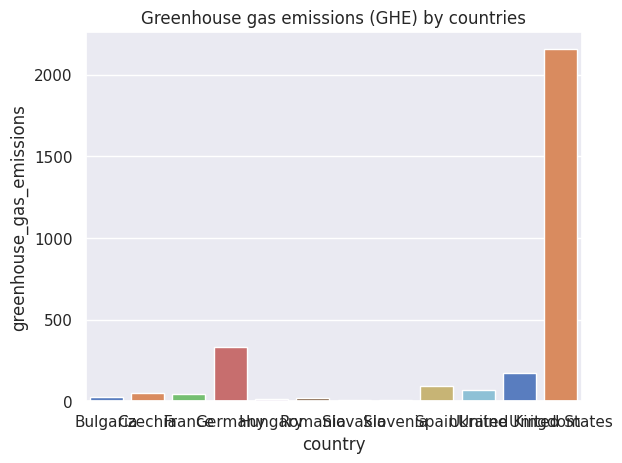

In [14]:
# Barplot
sns.barplot(x='country', y='greenhouse_gas_emissions', hue='country', data=df, \
            errorbar=None, palette='muted', legend=False )
plt.title('Greenhouse gas emissions (GHE) by countries')
plt.show()

In [15]:
#Partitioning the continuous data into 3 categories for ANOVA
df['fossil_level'] = pd.qcut(df['fossil_fuel_consumption'], q=3, labels=['Low', 'Medium', 'High'])
df['coal_level'] = pd.qcut(df['coal_consumption'], q=2, labels=['Low_C', 'High_C'])
df['gas_level'] = pd.qcut(df['gas_consumption'], q=2, labels=['Low_G', 'High_G'])

In [17]:
# One-Way ANOVA
model_1way = ols('greenhouse_gas_emissions ~ C(fossil_level)', data=df).fit()
anova_1way = sm.stats.anova_lm(model_1way, typ=2)
print(anova_1way)

# Interpretation
# If p-value < 0.05, reject null hypothesis
# F-statistic = ratio of between-group to within-group variation.

                       sum_sq     df          F        PR(>F)
C(fossil_level)  4.443431e+07    2.0  72.887433  1.685574e-21
Residual         3.688257e+07  121.0        NaN           NaN


In [18]:
# Interpretation Logic
p_value_overall = model_1way.f_pvalue
if p_value_overall < 0.05:
    print(f"\nResult: Reject the Null Hypothesis (p-value: {p_value_overall:.4e})")
    print("Conclusion: NRE consumptions significantly contribute to greenhouse gas emissions.")
else:
    print(f"\nResult: Fail to Reject the Null Hypothesis (p-value: {p_value_overall:.4f})")
    print("Conclusion: There is no significant evidence that NRE consumptions affect GHG emissions.")


Result: Reject the Null Hypothesis (p-value: 1.6856e-21)
Conclusion: NRE consumptions significantly contribute to greenhouse gas emissions.


In [19]:
# Two-Way ANOVA (GHE ×  coal & gas level)
model_2way = ols('greenhouse_gas_emissions ~ C(coal_level) * C(gas_level)', data=df).fit()
anova_2way = sm.stats.anova_lm(model_2way, typ=2)
print(anova_2way)

# Interpretation
# coal_level: main effect of coal energy on GHE
# gas_level: main effect of gas level on GHE
#coal_level:gas_level -> interactiom effect

                                  sum_sq     df          F    PR(>F)
C(coal_level)               4.737102e+06    1.0  12.051670  0.000720
C(gas_level)                4.890686e+06    1.0  12.442405  0.000596
C(coal_level):C(gas_level)  4.304354e+06    1.0  10.950715  0.001236
Residual                    4.716792e+07  120.0        NaN       NaN


In [20]:
#Interpretation Logic
p_value_overall = model_2way.f_pvalue
if p_value_overall < 0.05:
    print(f"\nResult: Reject the Null Hypothesis (p-value: {p_value_overall:.4e})")

else:
    print(f"\nResult: Fail to Reject the Null Hypothesis (p-value: {p_value_overall:.4f})")


Result: Reject the Null Hypothesis (p-value: 3.7036e-14)


In [21]:
#Post-Hoc test
#Tukey's HSD for One-way ANOVA
#Comparing high, medium and low fossil fuel consumption
tukey_1way = pairwise_tukeyhsd(endog=df['greenhouse_gas_emissions'],
                              groups=df['fossil_level'],
                              alpha=0.05)

#Tukey's HSD for Two-way ANOVA
#to create a combined factor to compare all possible group combinations (e.g: high coal + low gas)
df['interaction_factor'] = df['coal_level'].astype(str) + "_" + df['gas_level'].astype(str)
tukey_2way = pairwise_tukeyhsd(endog=df['greenhouse_gas_emissions'],
                              groups=df['interaction_factor'],
                              alpha=0.05)

print("--- Tukey HSD One-way Results ---")
print(tukey_1way)
print("\n--- Tukey HSD Two-way Results ---")
print(tukey_2way)

--- Tukey HSD One-way Results ---
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
group1 group2  meandiff  p-adj    lower      upper   reject
-----------------------------------------------------------
  High    Low -1303.2368    0.0 -1590.8576 -1015.616   True
  High Medium -1222.6695    0.0 -1510.2902 -935.0487   True
   Low Medium    80.5673 0.7866  -208.7809  369.9155  False
-----------------------------------------------------------

--- Tukey HSD Two-way Results ---
          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
    group1       group2     meandiff  p-adj    lower      upper   reject
------------------------------------------------------------------------
High_C_High_G High_C_Low_G -1046.5257    0.0  -1610.554 -482.4974   True
High_C_High_G Low_C_High_G -1037.9797    0.0  -1602.008 -473.9514   True
High_C_High_G  Low_C_Low_G -1071.3802    0.0 -1391.7268 -751.0336   True
 High_C_Low_G Low_C_High_G      8.546    1.0  -721.9565  739.0485  False


In [ ]:
#Levene's test: one-way ANOVA groups
#used to test for homogeneity of variances
f_low = df[df['fossil_level'] == 'Low']['greenhouse_gas_emissions']
f_med = df[df['fossil_level'] == 'Medium']['greenhouse_gas_emissions']
f_high = df[df['fossil_level'] == 'High']['greenhouse_gas_emissions']

levene_1way = stats.levene(f_low, f_med, f_high)

#Levene's Test for Two-way ANOVA groups (all combinations of coal and gas consumptions)
twoway_groups = [
    df[(df['coal_level'] == c) & (df['gas_level'] == g)]['greenhouse_gas_emissions']
    for c in ['Low', 'High'] for g in ['Low', 'High']
]
levene_2way = stats.levene(*twoway_groups)

print("--- Levene's Test Results ---")
print(f"One-way Groups: Statistic={levene_1way.statistic:.4f}, p-value={levene_1way.pvalue:.4e}")
print(f"Two-way Groups: Statistic={levene_2way.statistic:.4f}, p-value={levene_2way.pvalue:.4e}")

--- Levene's Test Results ---
One-way Groups: Statistic=96.2833, p-value=9.5624e-26
Two-way Groups: Statistic=20.1622, p-value=1.1965e-10


In [ ]:
#Shapiro-Wilk test (Normality test)
#Testing the residuals of the models
shapiro_1way = stats.shapiro(model_1way.resid)
shapiro_2way = stats.shapiro(model_2way.resid)

print("--- Shapiro-Wilk Test Results (Normality of Residuals) ---")
print(f"One-way ANOVA: W={shapiro_1way.statistic:.4f}, p-value={shapiro_1way.pvalue:.4e}")
print(f"Two-way ANOVA: W={shapiro_2way.statistic:.4f}, p-value={shapiro_2way.pvalue:.4e}")

--- Shapiro-Wilk Test Results (Normality of Residuals) ---
One-way ANOVA: W=0.8219, p-value=6.0068e-11
Two-way ANOVA: W=0.8486, p-value=6.2314e-10


/tmp/ipykernel_2132/4156966334.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fossil_level', y='greenhouse_gas_emissions', data=df,


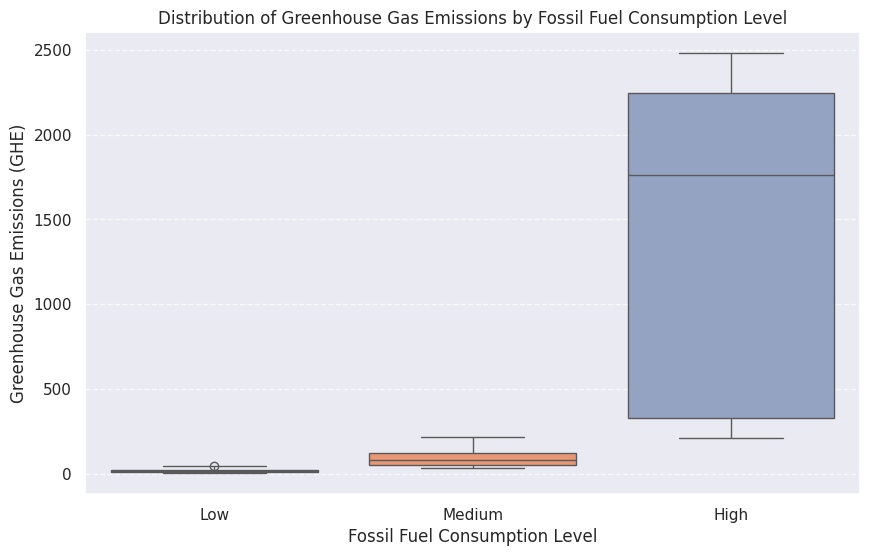

In [22]:
#Generate boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='fossil_level', y='greenhouse_gas_emissions', data=df,
            order=['Low', 'Medium', 'High'], palette='Set2')
plt.title('Distribution of Greenhouse Gas Emissions by Fossil Fuel Consumption Level')
plt.xlabel('Fossil Fuel Consumption Level')
plt.ylabel('Greenhouse Gas Emissions (GHE)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

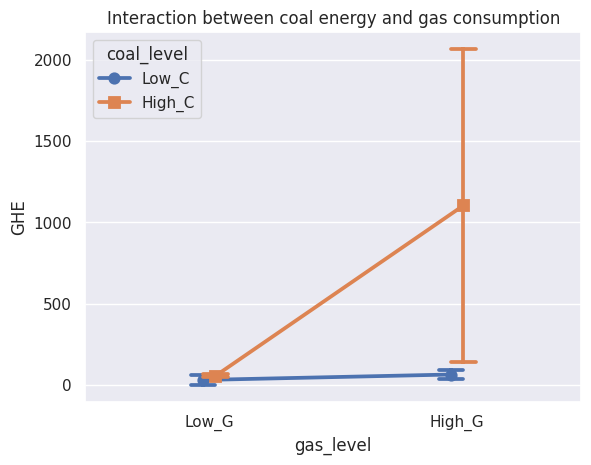

In [23]:
#Interaction Plot
#If lines are not parallel → interaction effect exists.

sns.pointplot(x='gas_level', y='greenhouse_gas_emissions', hue='coal_level', data=df,
             errorbar='sd', dodge=True, markers=['o', 's'], capsize=.1)
plt.title('Interaction between coal energy and gas consumption')
plt.ylabel('GHE')
plt.show()